# Toy Data Evaluation

In [36]:
import Evaluation as E

recall = E.Recall([5,14,19,6,11,3,2,10,200,15,17,12,131,89],[90,11,5,6,10,60,14,89,19,200],toyData=True,N=30)
f1_score = E.F1_score([5,14,19,6,11,3,2,10,200,15,17,12,131,89],[90,11,5,6,10,60,14,89,19,200],toyData=True,N=30)
precission = E.Precision([5,14,19,6,11,3,2,10,200,15,17,12,131,89],[90,11,5,6,10,60,14,89,19,200],toyData=True,N=30)
ap = E.AP([5,14,19,6,11,3,2,10,200,15,17,12,131,89],[90,11,5,6,10,60,14,89,19,200],toyData=True,N=30)

[0, 1, 2, 3, 4, 4, 5, 6, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
[0, 1, 2, 3, 4, 4, 5, 6, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]


c:\HybridCollaborativeFiltering\Hybrid-Collaborative-Filtering-HCF\Evaluation\F1_score.py:21: RuntimeWarning: invalid value encountered in divide
  return self.numerator(u,indexFold=indexFold)/self.denominator(u,indexFold=indexFold)


In [42]:
print("precission : ",precission.result_evaluation)
print("=="*99)
print("Recall : ",recall.result_evaluation)
print("=="*99)
print("f1_score : ",f1_score.result_evaluation)
print("=="*99)
print("AP : ",ap.result_evaluation)

precission :  [0.         0.5        0.66666667 0.75       0.8        0.66666667
 0.71428571 0.75       0.77777778 0.8        0.8        0.8
 0.8        0.8        0.8        0.8        0.8        0.8
 0.8        0.8        0.8        0.8        0.8        0.8
 0.8        0.8        0.8        0.8        0.8        0.8       ]
Recall :  [0.         0.07142857 0.14285714 0.21428571 0.28571429 0.28571429
 0.35714286 0.42857143 0.5        0.57142857 0.57142857 0.57142857
 0.57142857 0.57142857 0.57142857 0.57142857 0.57142857 0.57142857
 0.57142857 0.57142857 0.57142857 0.57142857 0.57142857 0.57142857
 0.57142857 0.57142857 0.57142857 0.57142857 0.57142857 0.57142857]
f1_score :  [       nan 0.125      0.23529412 0.33333333 0.42105263 0.4
 0.47619048 0.54545455 0.60869565 0.66666667 0.66666667 0.66666667
 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667
 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667
 0.66666667 0.66666667 0.66666667 0.66666667 0.66666

# Helper


In [1]:
def skenario_pertama_tversky_index(data) :
    from itertools import product

    skenario_recall = data.result_skenario[0.7][30][20]

    gamma = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]


    ti_gamma_alpha_recall = []
    # Mengakses parameter gamma
    ti_mean_gamma_overall_fold_recall = []
    for gamma_index_1, gamma_index_2 in product(gamma,gamma) :
        
        skenario = skenario_recall[gamma_index_1][gamma_index_2]
        
        ti_mean_gamma_fold_recall = []

        for fold in skenario :

            # Tahap 1
            ti_sum_matrix_recall = sum([i[99] for i in fold]) 
            ti_mean_gamma_fold_recall.append(ti_sum_matrix_recall/len(fold))
        
        # Tahap 3
        ti_mean_matrix_per_fold_recall = sum(ti_mean_gamma_fold_recall)/len(skenario)
        
        ti_mean_gamma_fold_recall.append(ti_mean_matrix_per_fold_recall)
        ti_mean_gamma_overall_fold_recall.append(ti_mean_gamma_fold_recall)

        return ti_mean_gamma_overall_fold_recall

def visualisasi_skenario_pertama_tversky_index(data) :
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    alpha = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
    # Ambil kolom rata-rata dari ti_mean_gamma_overall_fold_recall
    rata_rata = np.array(data)[:, -1]

    # Ubah menjadi matriks 11x11 sesuai alpha_1 dan alpha_2
    heatmap_matrix = rata_rata.reshape(len(alpha), len(alpha))

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap="viridis", 
                xticklabels=alpha, yticklabels=alpha, cbar_kws={'label': 'Recall rata-rata'})
    plt.xlabel(r'$\alpha_2$')
    plt.ylabel(r'$\alpha_1$')
    plt.title(r'Heatmap Recall rata-rata: $\alpha_1$ vs $\alpha_2$')
    plt.show()


## Kedua TI

In [9]:
def skenario_kedua_tversky_index(skenario : object) :
    import numpy as np

    n = 100
    k_user = [5,10,15,18,20,25,30,40,50,100,200]


    ti_k_user_fold = []
    ti_mean_k_user_fold = []

    # Mengakses parameter k_user
    for k_user_index in k_user :

        skenario_kedua_k_user = skenario.result_skenario[0.7][k_user_index][20][0.1][0]
        ti_mean_k_user_per_fold = []

        for fold in skenario_kedua_k_user :
            # Tahap 1 : menjumlahkan evaluasi setiap fold
            ti_sum_k_user_per_fold = sum(j[99] for j in fold)
            ti_mean_k_user_per_fold += [ti_sum_k_user_per_fold/len(skenario_kedua_k_user)]
        
        # Tahap 3 : menghitung rata-rata setiap fold dengan menjumlahkan nilai evaluasi setiap pengguna dibagi dengan banyaknya pengguna
        mean_k_user_per_fold = sum(ti_mean_k_user_per_fold)/len(skenario_kedua_k_user)
        
        ti_mean_k_user_per_fold += [mean_k_user_per_fold]
        ti_k_user_fold += [ti_mean_k_user_per_fold]
        ti_mean_k_user_fold += [[5,k_user_index,mean_k_user_per_fold]]

    return {
        "result" : ti_k_user_fold,
        "mean" : ti_mean_k_user_fold,
    }

def df_skenario_kedua_tversky_index(dataProcess, type = "result"):
    import pandas as pd

    k_user = [5,10,15,18,20,25,30,40,50,100,200]

    return pd.DataFrame(dataProcess[type],index=[ f"A1_{str(0.1)}_A2_{str(0)}_N_{i}" for i in k_user],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

def visualisation_skenario_kedua_tversky_index_per_fold(dataProcess, type, title) :
    import matplotlib.pyplot as plt
    k_user = [5,10,15,18,20,25,30,40,50,100,200]

    if type == "result" :
        # Definisikan markers dan colors
        # markers = ['o', 's', '^', 'D', 'o']
        colors = ['b', 'g', 'r', 'c', 'm']

        plt.figure(figsize=(10, 6))

        for fold_idx in range(5):
            per_fold = [dataProcess["result"][k][fold_idx] for k in range(len(k_user))]
            plt.plot(
                k_user,
                per_fold,
                marker="o",
                color=colors[fold_idx],
                label=f'Fold-{fold_idx+1}'
            )
        plt.legend()

    elif type == "mean" :
        import pandas as pd
        df = pd.DataFrame(dataProcess["mean"], index=[i for i in range(1, len(dataProcess["mean"]) + 1)], columns=["k_user", "k_item", "recall"])

        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 6))
        plt.plot(k_user, df["recall"], marker='o')
    
    plt.xlabel(r'$k^{user}$')
    plt.ylabel(title)
    plt.title(title+r' per Fold untuk Setiap $k^{user}$')
    plt.grid(True)
    plt.show()

# Recall

### Skenario mencari $\alpha_1$ dan $\alpha_2$

#### Tversky Index

In [ ]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [30],
            "k_item" : [20],
            "alpha_1" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
            "alpha_2" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
        }

ti_skenario_pertama_recall = EksperimenHCF("data/ml-100k",Evaluation=E.Recall,object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/recall/FBO_A1_and_A2_v3.joblib",N=100,n=100)

In [30]:
from itertools import product
import numpy as np
import pandas as pd

skenario_recall = ti_skenario_pertama_recall.result_skenario[0.7][30][20]

gamma = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]


ti_gamma_alpha_recall = []
# Mengakses parameter gamma
ti_mean_gamma_overall_fold_recall = []
for gamma_index_1, gamma_index_2 in product(gamma,gamma) :
    
    skenario = skenario_recall[gamma_index_1][gamma_index_2]
    
    ti_mean_gamma_fold_recall = []

    for fold in skenario :

        # Tahap 1
        ti_sum_matrix_recall = sum([i[99] for i in fold]) 
        ti_mean_gamma_fold_recall.append(ti_sum_matrix_recall/len(fold))
    
    # Tahap 3
    ti_mean_matrix_per_fold_recall = sum(ti_mean_gamma_fold_recall)/len(skenario)
    
    ti_mean_gamma_fold_recall.append(ti_mean_matrix_per_fold_recall)
    ti_mean_gamma_overall_fold_recall.append(ti_mean_gamma_fold_recall)

In [31]:
import pandas as pd
import itertools
alpha = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(ti_mean_gamma_overall_fold_recall,index=[ f"A1_{str(i)}_A2_{str(j)}" for i,j in itertools.product(alpha,alpha)],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.0_A2_0.0,41.423638,24.568075,14.653616,13.368918,15.518687,21.906587
A1_0.0_A2_0.1,37.428604,18.465503,10.950960,9.280843,11.064196,17.438021
A1_0.0_A2_0.2,36.462040,18.224287,10.755215,8.967126,11.059351,17.093604
A1_0.0_A2_0.3,36.368752,17.929625,10.614523,9.086683,11.046807,17.009278
A1_0.0_A2_0.4,36.274301,17.862030,10.517589,8.852306,11.005524,16.902350
...,...,...,...,...,...,...
A1_1.0_A2_0.6,49.288647,25.177060,16.114686,14.617236,16.463987,24.332323
A1_1.0_A2_0.7,48.476228,24.685988,16.014833,14.506869,16.180837,23.972951
A1_1.0_A2_0.8,48.242854,24.840958,15.916339,14.452738,16.039327,23.898443
A1_1.0_A2_0.9,48.079089,24.301328,15.490224,14.471681,15.946659,23.657796


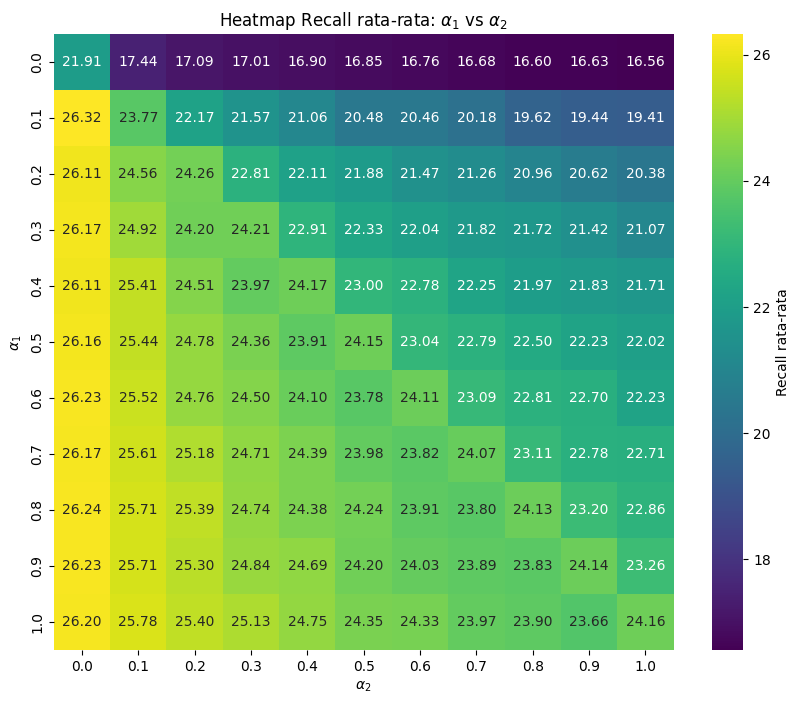

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ambil kolom rata-rata dari ti_mean_gamma_overall_fold_recall
rata_rata = np.array(ti_mean_gamma_overall_fold_recall)[:, -1]

# Ubah menjadi matriks 11x11 sesuai alpha_1 dan alpha_2
heatmap_matrix = rata_rata.reshape(len(alpha), len(alpha))

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap="viridis", 
            xticklabels=alpha, yticklabels=alpha, cbar_kws={'label': 'Recall rata-rata'})
plt.xlabel(r'$\alpha_2$')
plt.ylabel(r'$\alpha_1$')
plt.title(r'Heatmap Recall rata-rata: $\alpha_1$ vs $\alpha_2$')
plt.show()


## Skenario mencari $k^{user}$

#### Tversky Index

In [7]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [20],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

ti_skenario_kedua_recall = EksperimenHCF("data/ml-100k",Evaluation=E.Recall,object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/recall/FBO_K_user.joblib",N=100,n=None)

In [17]:
import numpy as np

# n = 100
# k_user = [5,10,15,18,20,25,30,40,50,100,200]


# ti_k_user_fold = []
# ti_mean_k_user_fold = []

# # Mengakses parameter k_user
# for k_user_index in k_user :

#     skenario_kedua_k_user = ti_skenario_pertama_recall.result_skenario[0.7][k_user_index][20][0.1][0]
#     ti_mean_k_user_per_fold = []

#     for fold in skenario_kedua_k_user :
#         # Tahap 1 : menjumlahkan evaluasi setiap fold
#         ti_sum_k_user_per_fold = sum(j[99] for j in fold)
#         ti_mean_k_user_per_fold += [ti_sum_k_user_per_fold/len(skenario_kedua_k_user)]
    
#     # Tahap 3 : menghitung rata-rata setiap fold dengan menjumlahkan nilai evaluasi setiap pengguna dibagi dengan banyaknya pengguna
#     mean_k_user_per_fold = sum(ti_mean_k_user_per_fold)/len(skenario_kedua_k_user)
    
#     ti_mean_k_user_per_fold += [mean_k_user_per_fold]
#     ti_k_user_fold += [ti_mean_k_user_per_fold]
#     ti_mean_k_user_fold += [[5,k_user_index,mean_k_user_per_fold]]

data_process_recall_ti_kedua = skenario_kedua_tversky_index(ti_skenario_kedua_recall)

In [22]:
df_skenario_kedua_tversky_index(data_process_recall_ti_kedua)

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.1_A2_0_N_5,4754.736565,3670.949029,3452.590244,3456.317096,3645.884332,3796.095453
A1_0.1_A2_0_N_10,4844.791875,3757.434662,3380.229488,3485.092278,3784.389007,3850.387462
A1_0.1_A2_0_N_15,4881.998424,3655.263790,3251.663328,3353.572740,3686.560904,3765.811837
A1_0.1_A2_0_N_18,4800.443938,3693.352391,3210.075435,3320.990827,3590.645435,3723.101605
A1_0.1_A2_0_N_20,4819.903093,3656.271912,3164.147756,3237.213950,3591.993111,3693.905964
A1_0.1_A2_0_N_25,4815.390870,3605.142874,3179.890288,3145.404967,3496.684460,3648.502692
A1_0.1_A2_0_N_30,4746.073816,3560.030425,3090.246067,3023.764726,3429.690406,3569.961088
A1_0.1_A2_0_N_40,4744.052967,3542.866772,2956.598795,2921.409522,3283.407822,3489.667176
A1_0.1_A2_0_N_50,4611.987235,3429.338982,2809.061913,2760.421393,3181.617443,3358.485393
A1_0.1_A2_0_N_100,4363.685473,3199.785802,2582.489453,2504.187447,2949.157417,3119.861118


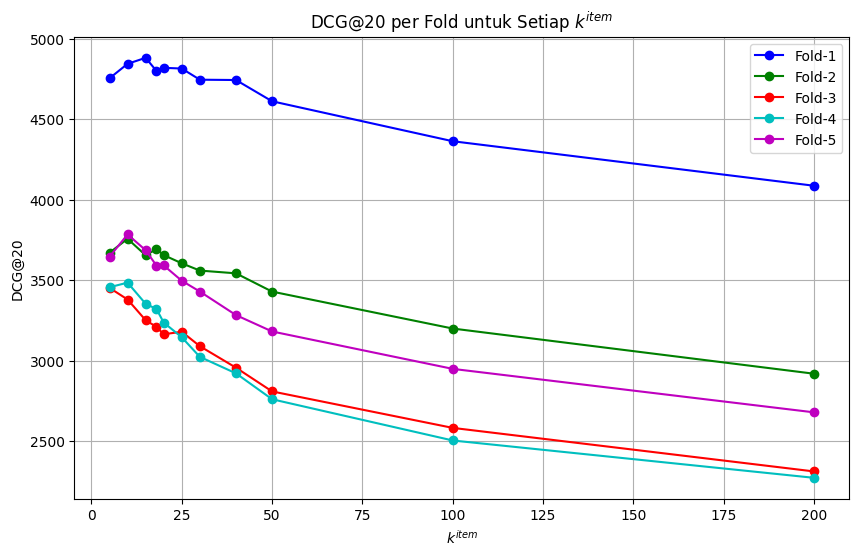

In [7]:
import matplotlib.pyplot as plt

# Definisikan markers dan colors
# markers = ['o', 's', '^', 'D', 'o']
colors = ['b', 'g', 'r', 'c', 'm']

plt.figure(figsize=(10, 6))

for fold_idx in range(5):
    dcg_per_fold = [dataProcess["result"][k][fold_idx] for k in range(len(k_user))]
    plt.plot(
        k_user,
        dcg_per_fold,
        marker="o",
        color=colors[fold_idx],
        label=f'Fold-{fold_idx+1}'
    )

plt.xlabel(r'$k^{item}$')
plt.ylabel('DCG@20')
plt.title(r'DCG@20 per Fold untuk Setiap $k^{item}$')
plt.legend()
plt.grid(True)
plt.show()

11


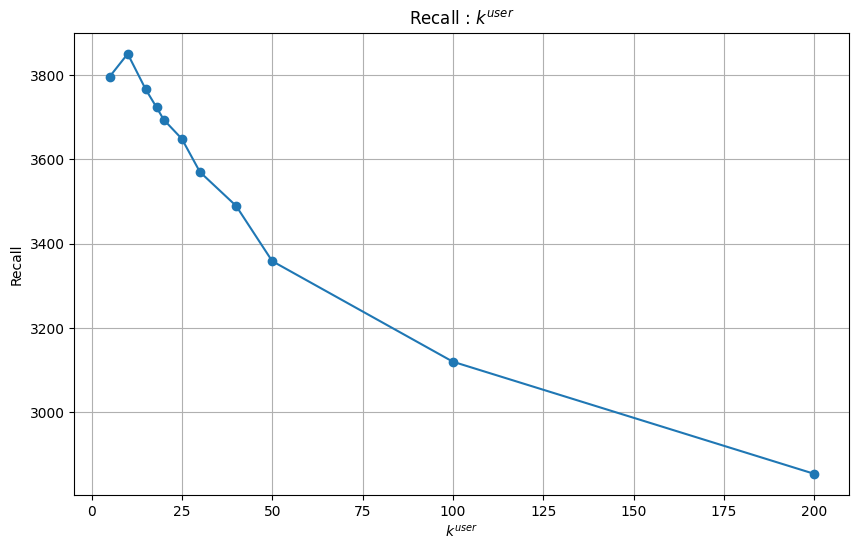

In [9]:
import pandas as pd
print(len(dataProcess["mean"]))
df = pd.DataFrame(dataProcess["mean"], index=[i for i in range(1, len(dataProcess["mean"]) + 1)], columns=["k_user", "k_item", "recall"])

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["recall"], marker='o')
plt.xlabel(r"$k^{user}$")
plt.ylabel("Recall")
plt.title(r"Recall : $k^{user}$")
plt.grid(True)
plt.show()

### Dice Coefficient

In [2]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [20],
        }

dc_skenario_pertama_recall = EksperimenHCF("data/ml-100k",Evaluation=E.Recall,object=S.DC,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],path_file="Eksperimen/dice_coefficient/recall/FBO_A1_and_A2.joblib",N=100,n=None)

## Skenario mencari $k^{item}$

### Tversky Index

In [68]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [10],
            "k_item" : [5,10,15,18,20,25,30,40,50,100,200],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

ti_skenario_ketiga_recall = EksperimenHCF("data/ml-100k",Evaluation=E.Recall,object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/recall/FBO_K_item.joblib",N=100,n=100)

  0%|          | 0/11 [00:00<?, ?it/s]

Prediction Hybrid Collaborative Filtering: 100%|██████████| 5/5 [00:23<00:00,  4.68s/it]


# F1 Score

### Skenario Mencari $\alpha_1$ dan $\alpha_2$

#### Tversky Index

In [ ]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [30],
            "k_item" : [20],
            "alpha_1" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
            "alpha_2" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
        }

ti_skenario_pertama_f1_score = EksperimenHCF("data/ml-100k",Evaluation=E.F1_score,object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/f1_score/FBO_A1_and_A2.joblib",N=100,n=100)

In [33]:
from itertools import product
import numpy as np
import pandas as pd

skenario_f1_score = ti_skenario_pertama_f1_score.result_skenario[0.7][30][20]

gamma = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]


ti_gamma_alpha_f1_score = []
# Mengakses parameter gamma
ti_mean_gamma_overall_fold_f1_score = []
for gamma_index_1, gamma_index_2 in product(gamma,gamma) :
    
    skenario = skenario_f1_score[gamma_index_1][gamma_index_2]
    
    ti_mean_gamma_fold_f1_score = []

    for fold in skenario :

        # Tahap 1
        ti_sum_matrix_f1_score = sum([i[99] for i in fold]) 
        ti_mean_gamma_fold_f1_score.append(ti_sum_matrix_f1_score/len(fold))
    
    # Tahap 3
    ti_mean_matrix_per_fold_f1_score = sum(ti_mean_gamma_fold_f1_score)/len(skenario)
    
    ti_mean_gamma_fold_f1_score.append(ti_mean_matrix_per_fold_f1_score)
    ti_mean_gamma_overall_fold_f1_score.append(ti_mean_gamma_fold_f1_score)

In [34]:
import pandas as pd
import itertools
alpha = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(ti_mean_gamma_overall_fold_f1_score,index=[ f"A1_{str(i)}_A2_{str(j)}" for i,j in itertools.product(alpha,alpha)],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.0_A2_0.0,41.423638,24.568075,14.653616,13.368918,15.518687,21.906587
A1_0.0_A2_0.1,37.428604,18.465503,10.950960,9.280843,11.064196,17.438021
A1_0.0_A2_0.2,36.462040,18.224287,10.755215,8.967126,11.059351,17.093604
A1_0.0_A2_0.3,36.368752,17.929625,10.614523,9.086683,11.046807,17.009278
A1_0.0_A2_0.4,36.274301,17.862030,10.517589,8.852306,11.005524,16.902350
...,...,...,...,...,...,...
A1_1.0_A2_0.6,49.288647,25.177060,16.114686,14.617236,16.463987,24.332323
A1_1.0_A2_0.7,48.476228,24.685988,16.014833,14.506869,16.180837,23.972951
A1_1.0_A2_0.8,48.242854,24.840958,15.916339,14.452738,16.039327,23.898443
A1_1.0_A2_0.9,48.079089,24.301328,15.490224,14.471681,15.946659,23.657796


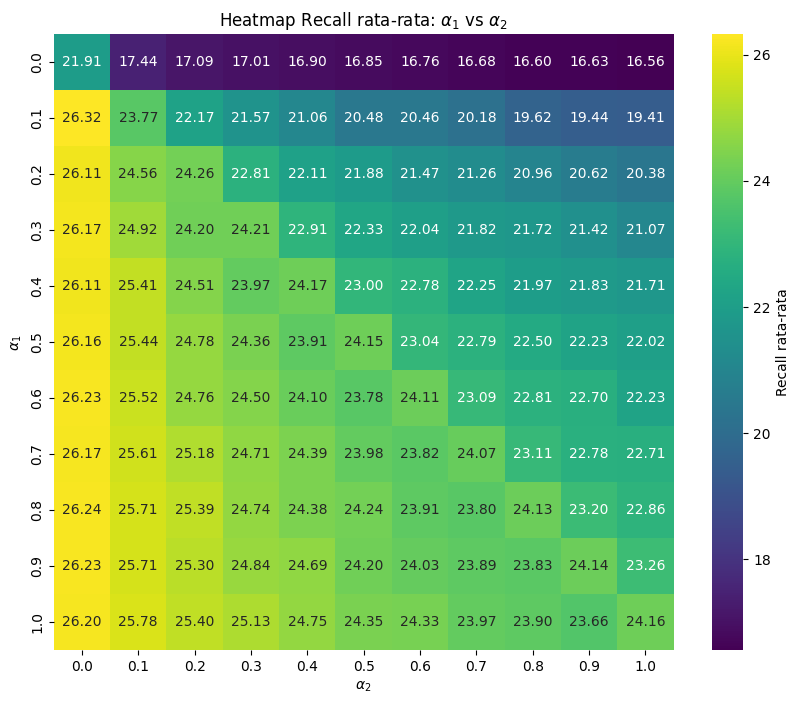

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ambil kolom rata-rata dari ti_mean_gamma_overall_fold_ap
rata_rata = np.array(ti_mean_gamma_overall_fold_f1_score)[:, -1]

# Ubah menjadi matriks 11x11 sesuai alpha_1 dan alpha_2
heatmap_matrix = rata_rata.reshape(len(alpha), len(alpha))

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap="viridis", 
            xticklabels=alpha, yticklabels=alpha, cbar_kws={'label': 'Recall rata-rata'})
plt.xlabel(r'$\alpha_2$')
plt.ylabel(r'$\alpha_1$')
plt.title(r'Heatmap Recall rata-rata: $\alpha_1$ vs $\alpha_2$')
plt.show()


### Skenario mencari $k^{user}$

#### Tversky Index

In [12]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [20],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

ti_skenario_kedua_f1_score = EksperimenHCF("data/ml-100k",Evaluation=E.F1_score,object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/f1_score/FBO_K_user.joblib",N=100,n=None)

In [20]:
data_process_f1_score_ti_kedua = skenario_kedua_tversky_index(ti_skenario_kedua_f1_score)

In [21]:
df_skenario_kedua_tversky_index(data_process_f1_score_ti_kedua)

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.1_A2_0_N_5,4754.736565,3670.949029,3452.590244,3456.317096,3645.884332,3796.095453
A1_0.1_A2_0_N_10,4844.791875,3757.434662,3380.229488,3485.092278,3784.389007,3850.387462
A1_0.1_A2_0_N_15,4881.998424,3655.263790,3251.663328,3353.572740,3686.560904,3765.811837
A1_0.1_A2_0_N_18,4800.443938,3693.352391,3210.075435,3320.990827,3590.645435,3723.101605
A1_0.1_A2_0_N_20,4819.903093,3656.271912,3164.147756,3237.213950,3591.993111,3693.905964
A1_0.1_A2_0_N_25,4815.390870,3605.142874,3179.890288,3145.404967,3496.684460,3648.502692
A1_0.1_A2_0_N_30,4746.073816,3560.030425,3090.246067,3023.764726,3429.690406,3569.961088
A1_0.1_A2_0_N_40,4744.052967,3542.866772,2956.598795,2921.409522,3283.407822,3489.667176
A1_0.1_A2_0_N_50,4611.987235,3429.338982,2809.061913,2760.421393,3181.617443,3358.485393
A1_0.1_A2_0_N_100,4363.685473,3199.785802,2582.489453,2504.187447,2949.157417,3119.861118


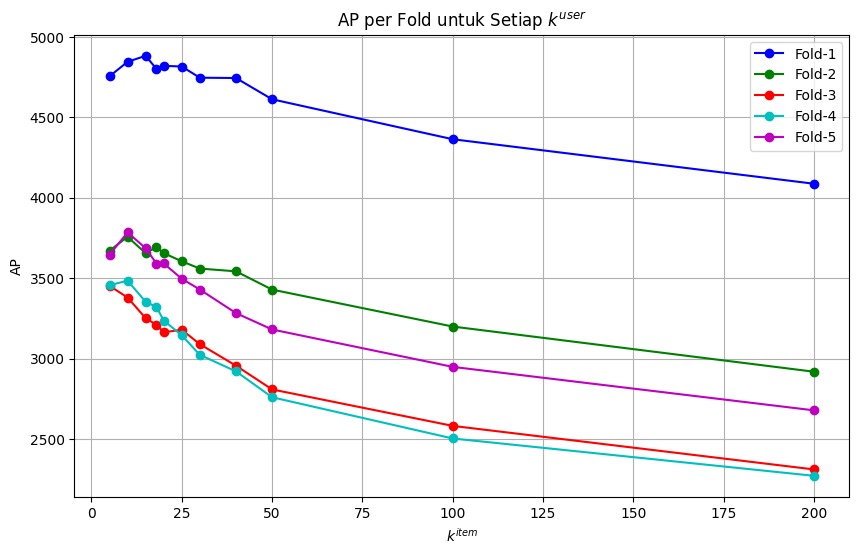

In [33]:
visualisation_skenario_kedua_tversky_index_per_fold(dataProcessAP, "result", "AP")

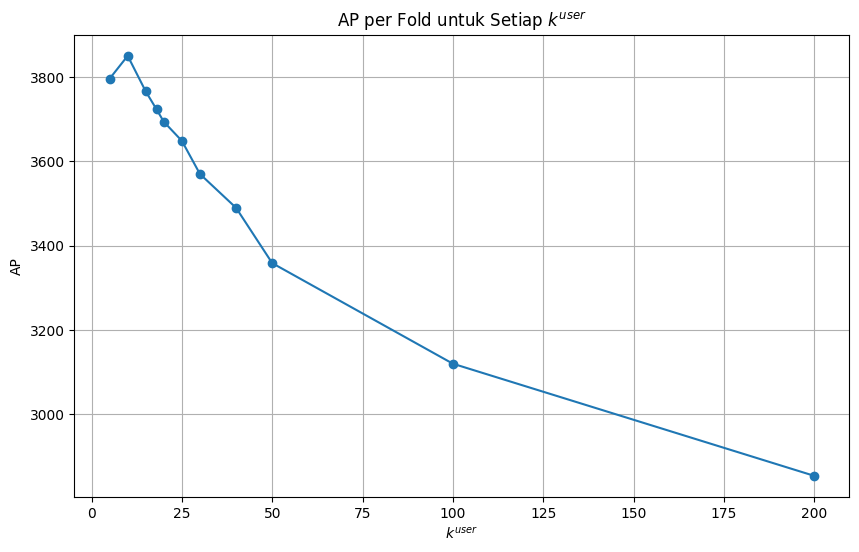

In [42]:
visualisation_skenario_kedua_tversky_index_per_fold(dataProcessAP, "mean", "AP")

#### Dice Coefficient

In [ ]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
                "k_item" : [20],
        }

skenario_pertama_f1_score = EksperimenHCF("data/ml-100k",Evaluation=E.F1_score,object=S.DC,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],path_file="Eksperimen/dice_coefficient/f1_score/FBO_A1_and_A2.joblib",N=100,n=None)

# Precision

### Skenario mencari $\alpha_1$ dan $\alpha_2$

#### Tversky Index

In [1]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [30],
            "k_item" : [20],
            "alpha_1" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
            "alpha_2" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
        }

ti_skenario_pertama_precission = EksperimenHCF("data/ml-100k",Evaluation=E.Precision,object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/precision/FBO_A1_and_A2.joblib",N=100,n=None)

In [3]:
from itertools import product
import numpy as np
import pandas as pd

skenario_precission = ti_skenario_pertama_precission.result_skenario[0.7][30][20]

gamma = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]


ti_gamma_alpha_precission = []
# Mengakses parameter gamma
ti_mean_gamma_overall_fold_precission = []
for gamma_index_1, gamma_index_2 in product(gamma,gamma) :
    
    skenario = skenario_precission[gamma_index_1][gamma_index_2]
    
    ti_mean_gamma_fold_precission = []

    for fold in skenario :

        # Tahap 1
        ti_sum_matrix_precission = sum([i[99] for i in fold]) 
        ti_mean_gamma_fold_precission.append(ti_sum_matrix_precission/len(fold))
    
    # Tahap 3
    ti_mean_matrix_per_fold_precission = sum(ti_mean_gamma_fold_precission)/len(skenario)
    
    ti_mean_gamma_fold_precission.append(ti_mean_matrix_per_fold_precission)
    ti_mean_gamma_overall_fold_precission.append(ti_mean_gamma_fold_precission)

In [4]:
import pandas as pd
import itertools
alpha = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(ti_mean_gamma_overall_fold_precission,index=[ f"A1_{str(i)}_A2_{str(j)}" for i,j in itertools.product(alpha,alpha)],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.0_A2_0.0,41.423638,24.568075,14.653616,13.368918,15.518687,21.906587
A1_0.0_A2_0.1,37.428604,18.465503,10.950960,9.280843,11.064196,17.438021
A1_0.0_A2_0.2,36.462040,18.224287,10.755215,8.967126,11.059351,17.093604
A1_0.0_A2_0.3,36.368752,17.929625,10.614523,9.086683,11.046807,17.009278
A1_0.0_A2_0.4,36.274301,17.862030,10.517589,8.852306,11.005524,16.902350
...,...,...,...,...,...,...
A1_1.0_A2_0.6,49.288647,25.177060,16.114686,14.617236,16.463987,24.332323
A1_1.0_A2_0.7,48.476228,24.685988,16.014833,14.506869,16.180837,23.972951
A1_1.0_A2_0.8,48.242854,24.840958,15.916339,14.452738,16.039327,23.898443
A1_1.0_A2_0.9,48.079089,24.301328,15.490224,14.471681,15.946659,23.657796


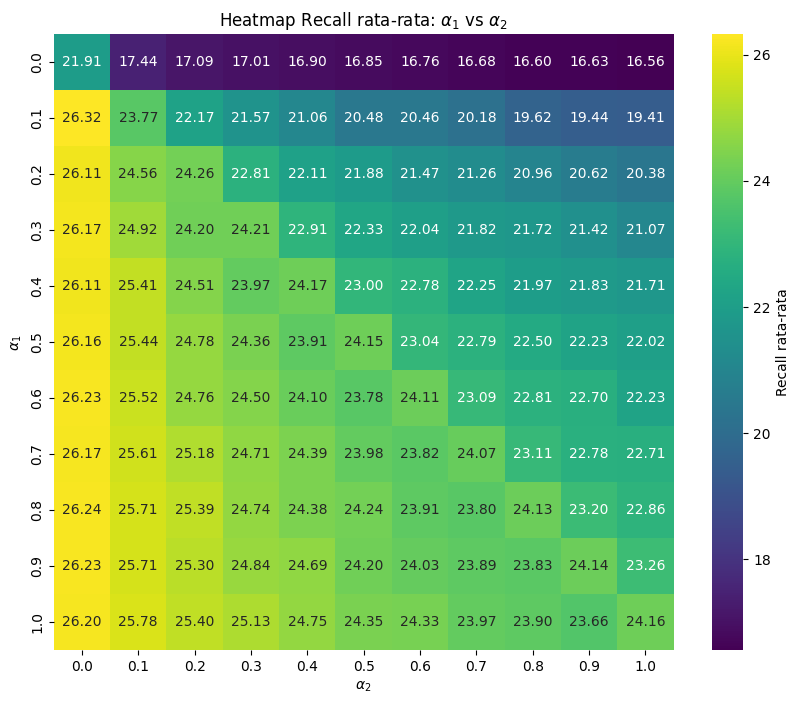

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ambil kolom rata-rata dari ti_mean_gamma_overall_fold_ap
rata_rata = np.array(ti_mean_gamma_overall_fold_precission)[:, -1]

# Ubah menjadi matriks 11x11 sesuai alpha_1 dan alpha_2
heatmap_matrix = rata_rata.reshape(len(alpha), len(alpha))

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap="viridis", 
            xticklabels=alpha, yticklabels=alpha, cbar_kws={'label': 'Recall rata-rata'})
plt.xlabel(r'$\alpha_2$')
plt.ylabel(r'$\alpha_1$')
plt.title(r'Heatmap Recall rata-rata: $\alpha_1$ vs $\alpha_2$')
plt.show()


### Skenario mencari $k^{user}$

#### Tversky Index

In [23]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [20],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

ti_skenario_kedua_precision = EksperimenHCF("data/ml-100k",Evaluation=E.Precision,object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/precision/FBO_K_user.joblib",N=100,n=None)

In [24]:
data_process_precision_ti_kedua = skenario_kedua_tversky_index(ti_skenario_kedua_precision)

In [25]:
df_skenario_kedua_tversky_index(data_process_precision_ti_kedua)

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.1_A2_0_N_5,4754.736565,3670.949029,3452.590244,3456.317096,3645.884332,3796.095453
A1_0.1_A2_0_N_10,4844.791875,3757.434662,3380.229488,3485.092278,3784.389007,3850.387462
A1_0.1_A2_0_N_15,4881.998424,3655.263790,3251.663328,3353.572740,3686.560904,3765.811837
A1_0.1_A2_0_N_18,4800.443938,3693.352391,3210.075435,3320.990827,3590.645435,3723.101605
A1_0.1_A2_0_N_20,4819.903093,3656.271912,3164.147756,3237.213950,3591.993111,3693.905964
A1_0.1_A2_0_N_25,4815.390870,3605.142874,3179.890288,3145.404967,3496.684460,3648.502692
A1_0.1_A2_0_N_30,4746.073816,3560.030425,3090.246067,3023.764726,3429.690406,3569.961088
A1_0.1_A2_0_N_40,4744.052967,3542.866772,2956.598795,2921.409522,3283.407822,3489.667176
A1_0.1_A2_0_N_50,4611.987235,3429.338982,2809.061913,2760.421393,3181.617443,3358.485393
A1_0.1_A2_0_N_100,4363.685473,3199.785802,2582.489453,2504.187447,2949.157417,3119.861118


#### Dice Coefficient

In [ ]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [20],
        }

skenario_pertama_precision = EksperimenHCF("data/ml-100k",Evaluation=E.Precision,object=S.DC,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],path_file="Eksperimen/dice_coefficient/precision/FBO_A1_and_A2.joblib",N=100,n=None)

# AP

### Skenario Mencari $\alpha_1$ dan $\alpha_2$

#### Tversky Index

In [1]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [30],
            "k_item" : [20],
            "alpha_1" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
            "alpha_2" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
        }

ti_skenario_pertama_ap = EksperimenHCF("data/ml-100k",Evaluation=E.AP,object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/ap/FBO_A1_and_A2.joblib",N=100,n=None)

In [5]:
from itertools import product
import numpy as np
import pandas as pd

skenario_ap = ti_skenario_pertama_ap.result_skenario[0.7][30][20]

gamma = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]


ti_gamma_alpha_ap = []
# Mengakses parameter gamma
ti_mean_gamma_overall_fold_ap = []
for gamma_index_1, gamma_index_2 in product(gamma,gamma) :
    
    skenario = skenario_ap[gamma_index_1][gamma_index_2]
    
    ti_mean_gamma_fold_ap = []

    for fold in skenario :

        # Tahap 1
        ti_sum_matrix_ap = sum([i[99] for i in fold]) 
        ti_mean_gamma_fold_ap.append(ti_sum_matrix_ap/len(fold))
    
    # Tahap 3
    ti_mean_matrix_per_fold_ap = sum(ti_mean_gamma_fold_ap)/len(skenario)
    
    ti_mean_gamma_fold_ap.append(ti_mean_matrix_per_fold_ap)
    ti_mean_gamma_overall_fold_ap.append(ti_mean_gamma_fold_ap)

In [6]:
import pandas as pd
import itertools
alpha = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(ti_mean_gamma_overall_fold_ap,index=[ f"A1_{str(i)}_A2_{str(j)}" for i,j in itertools.product(alpha,alpha)],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.0_A2_0.0,41.423638,24.568075,14.653616,13.368918,15.518687,21.906587
A1_0.0_A2_0.1,37.428604,18.465503,10.950960,9.280843,11.064196,17.438021
A1_0.0_A2_0.2,36.462040,18.224287,10.755215,8.967126,11.059351,17.093604
A1_0.0_A2_0.3,36.368752,17.929625,10.614523,9.086683,11.046807,17.009278
A1_0.0_A2_0.4,36.274301,17.862030,10.517589,8.852306,11.005524,16.902350
...,...,...,...,...,...,...
A1_1.0_A2_0.6,49.288647,25.177060,16.114686,14.617236,16.463987,24.332323
A1_1.0_A2_0.7,48.476228,24.685988,16.014833,14.506869,16.180837,23.972951
A1_1.0_A2_0.8,48.242854,24.840958,15.916339,14.452738,16.039327,23.898443
A1_1.0_A2_0.9,48.079089,24.301328,15.490224,14.471681,15.946659,23.657796


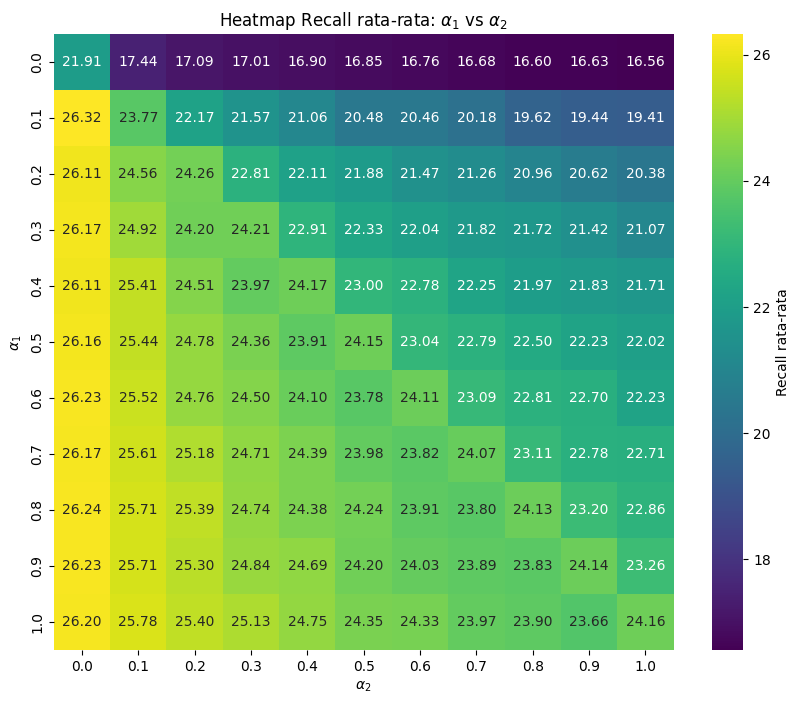

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ambil kolom rata-rata dari ti_mean_gamma_overall_fold_ap
rata_rata = np.array(ti_mean_gamma_overall_fold_ap)[:, -1]

# Ubah menjadi matriks 11x11 sesuai alpha_1 dan alpha_2
heatmap_matrix = rata_rata.reshape(len(alpha), len(alpha))

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap="viridis", 
            xticklabels=alpha, yticklabels=alpha, cbar_kws={'label': 'Recall rata-rata'})
plt.xlabel(r'$\alpha_2$')
plt.ylabel(r'$\alpha_1$')
plt.title(r'Heatmap Recall rata-rata: $\alpha_1$ vs $\alpha_2$')
plt.show()


### Skenario mencari $k^{user}$

#### Tversky Index

In [26]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [20],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

ti_skenario_kedua_AP = EksperimenHCF("data/ml-100k",Evaluation=E.AP,object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/ap/FBO_K_user.joblib",N=100,n=None)

In [27]:
data_process_AP_ti_kedua = skenario_kedua_tversky_index(ti_skenario_kedua_AP)

In [28]:
df_skenario_kedua_tversky_index(data_process_AP_ti_kedua)


,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.1_A2_0_N_5,4754.736565,3670.949029,3452.590244,3456.317096,3645.884332,3796.095453
A1_0.1_A2_0_N_10,4844.791875,3757.434662,3380.229488,3485.092278,3784.389007,3850.387462
A1_0.1_A2_0_N_15,4881.998424,3655.263790,3251.663328,3353.572740,3686.560904,3765.811837
A1_0.1_A2_0_N_18,4800.443938,3693.352391,3210.075435,3320.990827,3590.645435,3723.101605
A1_0.1_A2_0_N_20,4819.903093,3656.271912,3164.147756,3237.213950,3591.993111,3693.905964
A1_0.1_A2_0_N_25,4815.390870,3605.142874,3179.890288,3145.404967,3496.684460,3648.502692
A1_0.1_A2_0_N_30,4746.073816,3560.030425,3090.246067,3023.764726,3429.690406,3569.961088
A1_0.1_A2_0_N_40,4744.052967,3542.866772,2956.598795,2921.409522,3283.407822,3489.667176
A1_0.1_A2_0_N_50,4611.987235,3429.338982,2809.061913,2760.421393,3181.617443,3358.485393
A1_0.1_A2_0_N_100,4363.685473,3199.785802,2582.489453,2504.187447,2949.157417,3119.861118


#### Dice Coefficient

In [4]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S
import Evaluation as E

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [20],
        }

skenario_pertama_ap = EksperimenHCF("data/ml-100k",Evaluation=E.AP,object=S.DC,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],path_file="Eksperimen/dice_coefficient/ap/FBO_A1_and_A2.joblib",N=100,n=None)